#Import Libraries

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

#Load Dataset

In [24]:
df = pd.read_csv('bank-full.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


#Data Understanding (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


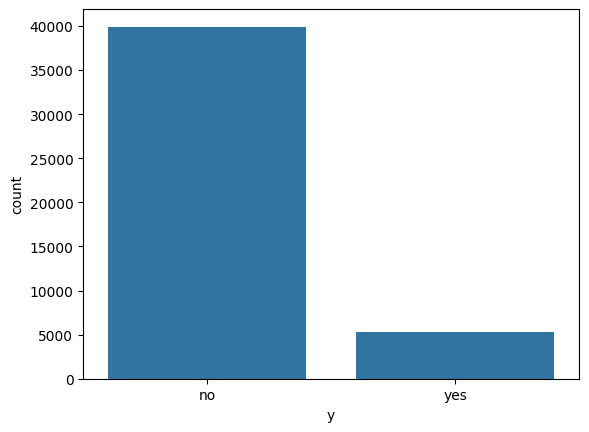

In [25]:
df.info()
df.describe()
df['y'].value_counts()
sns.countplot(x='y', data=df)
plt.show()

# Anomaly Detection


In [26]:

numeric_cols = ['age','balance','day','duration','campaign','pdays','previous']
for col in numeric_cols:
    zero_count = (df[col] == 0).sum()
    print(f"{col}: {zero_count} zeros")

print("pdays = -1 count:", (df['pdays'] == -1).sum())

categorical_cols = ['job','marital','education','contact','poutcome']
for col in categorical_cols:
    unknown_count = (df[col] == "unknown").sum()
    print(f"{col}: {unknown_count} unknowns")

age: 0 zeros
balance: 3514 zeros
day: 0 zeros
duration: 3 zeros
campaign: 0 zeros
pdays: 0 zeros
previous: 36954 zeros
pdays = -1 count: 36954
job: 288 unknowns
marital: 0 unknowns
education: 1857 unknowns
contact: 13020 unknowns
poutcome: 36959 unknowns


#Handling the amanolies

In [27]:
df['pdays'] = df['pdays'].replace(-1, pd.NA)
df = df.replace("unknown", pd.NA)

#Reading the current state


In [28]:
df = pd.read_csv("bank-full.csv", sep=";")
df['pdays'] = df['pdays'].replace(-1, pd.NA)
df = df.replace("unknown", pd.NA)

print(df.isna().sum())
print(df.describe())

age              0
job            288
marital          0
education     1857
default          0
balance          0
housing          0
loan             0
contact      13020
day              0
month            0
duration         0
campaign         0
pdays        36954
previous         0
poutcome     36959
y                0
dtype: int64
                age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102

In [30]:
df = pd.read_csv("bank-full.csv", sep=";")
df['pdays'] = df['pdays'].replace(-1, pd.NA)
df = df.replace("unknown", pd.NA)

df['job'] = df['job'].fillna(df['job'].mode()[0])
df['education'] = df['education'].fillna(df['education'].mode()[0])
df['contact'] = df['contact'].fillna("none")
df['poutcome'] = df['poutcome'].fillna("none")